# Task
Analyze the provided `customer_support_tickets.csv` data to build a predictive model for customer satisfaction, leveraging insights from `Customer Satisfaction Prediction ( ML _ FA _ DA projects ).pdf`, then visualize key findings and summarize the model's performance and factors influencing satisfaction.

## Understand Project Overview

### Subtask:
Read and summarize the `Customer Satisfaction Prediction ( ML _ FA _ DA projects ).pdf` to grasp the project's objectives, key metrics, and any specific approaches suggested. This will guide the subsequent data analysis and model building.


### Important Note: I cannot directly read PDF files.

To proceed with the subtask, please provide a summary of the `Customer Satisfaction Prediction ( ML _ FA _ DA projects ).pdf` document, focusing on the following aspects:

1.  **Overall goal or objective** of predicting customer satisfaction.
2.  **Definitions or explanations** of what constitutes 'customer satisfaction' within the project's context (e.g., specific metrics, survey scales).
3.  **Key metrics** mentioned for evaluating customer satisfaction or model performance.
4.  **Suggested methodologies, algorithms, or data preprocessing steps**.
5.  **Any specific features or data sources** highlighted as important.

Once you provide this summary, I can use it to guide the subsequent data analysis and model building for the `customer_support_tickets.csv` dataset.

## Load and Explore Data

### Subtask:
Load the `customer_support_tickets.csv` dataset and perform an initial exploratory data analysis (EDA). This includes checking data types, identifying missing values, understanding the distribution of key columns, and getting a general sense of the data to identify potential features and the target variable for customer satisfaction.


**Reasoning**:
First, I'll import the pandas library, load the `customer_support_tickets.csv` dataset, display its first few rows, and print a concise summary to get an initial overview of the data types and non-null values. This covers instructions 1-4.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/customer_support_tickets.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product se

**Reasoning**:
I'll check for missing values in each column to understand data completeness, which directly addresses instruction 5 of the subtask.



In [ ]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


**Reasoning**:
Next, I will generate descriptive statistics for numerical columns to understand their distribution, which addresses instruction 6 of the subtask.



In [ ]:
print("\nDescriptive statistics for numerical columns:")
print(df.describe())


Descriptive statistics for numerical columns:
         Ticket ID  Customer Age  Customer Satisfaction Rating
count  8469.000000   8469.000000                   2769.000000
mean   4235.000000     44.026804                      2.991333
std    2444.934048     15.296112                      1.407016
min       1.000000     18.000000                      1.000000
25%    2118.000000     31.000000                      2.000000
50%    4235.000000     44.000000                      3.000000
75%    6352.000000     57.000000                      4.000000
max    8469.000000     70.000000                      5.000000


**Reasoning**:
I will identify categorical columns and then print the unique values and their counts for each, which addresses instruction 7 of the subtask.



In [ ]:
print("\nUnique values and counts for categorical columns relevant to customer satisfaction:")
categorical_cols = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Type',
    'Ticket Subject',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]

for col in categorical_cols:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts())
    else:
        print(f"Column '{col}' not found in DataFrame.")


Unique values and counts for categorical columns relevant to customer satisfaction:

--- Customer Gender ---
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

--- Product Purchased ---
Product Purchased
Canon EOS                         240
GoPro Hero                        228
Nest Thermostat                   225
Amazon Echo                       221
Philips Hue Lights                221
LG Smart TV                       219
Sony Xperia                       217
Roomba Robot Vacuum               216
Apple AirPods                     213
LG OLED                           213
iPhone                            212
Sony 4K HDR TV                    210
LG Washing Machine                208
Garmin Forerunner                 208
Canon DSLR Camera                 206
Nikon D                           204
Nintendo Switch Pro Controller    203
Google Pixel                      203
Fitbit Charge                     202
Sony PlayStation                  20

### Potential Features and Target Variable Identification

Based on the initial exploration of the `customer_support_tickets.csv` dataset, the following observations lead to the identification of potential features and the target variable:

**Target Variable:**
- **`Customer Satisfaction Rating`**: This column directly represents the customer's satisfaction on a scale of 1 to 5, making it the most suitable target variable for our predictive model. It's important to note the significant number of missing values (5700 out of 8469), which indicates that satisfaction ratings are only available for closed tickets. This will need to be addressed during data preprocessing (e.g., by filtering or imputation strategies for the modeling phase).

**Potential Features:**
- **`Customer Age`**: A numerical column, `Customer Age` (ranging from 18 to 70), could influence satisfaction, as different age groups might have varying expectations or issues.
- **`Customer Gender`**: A categorical column with 'Male', 'Female', and 'Other' categories, which might show different satisfaction patterns.
- **`Product Purchased`**: A categorical column listing various products. The type of product purchased could be a significant factor in satisfaction.
- **`Ticket Type`**: Categorical (e.g., 'Refund request', 'Technical issue', 'Billing inquiry'). The nature of the ticket itself is likely a strong predictor of satisfaction.
- **`Ticket Subject`**: Categorical, providing more granular detail about the issue. This could be highly indicative of customer sentiment and resolution difficulty.
- **`Ticket Status`**: Categorical ('Pending Customer Response', 'Open', 'Closed'). The status of a ticket, especially whether it's closed and resolved, is directly linked to whether a satisfaction rating is available and likely impacts the rating itself.
- **`Ticket Priority`**: Categorical ('Critical', 'High', 'Medium', 'Low'). The perceived urgency or importance of an issue might correlate with customer expectations and satisfaction.
- **`Ticket Channel`**: Categorical ('Email', 'Phone', 'Social media', 'Chat'). The channel through which support was accessed could also play a role in satisfaction.
- **`First Response Time`** and **`Time to Resolution`**: These are currently object type but represent time-related metrics. Converting these into numerical features (e.g., duration in hours/days) could be highly valuable, as speed of response and resolution are critical factors for customer satisfaction. Both have missing values that would need careful handling.
- **`Ticket Description`** and **`Resolution`**: These are textual data columns. While not directly usable as numerical/categorical features, they could be processed using natural language processing (NLP) techniques (e.g., sentiment analysis, topic modeling) to extract additional features that might predict satisfaction.

## Data Preprocessing and Feature Engineering

### Subtask:
Clean the data, handle missing values, encode categorical variables, and engineer new features relevant for predicting customer satisfaction.


**Reasoning**:
First, I'll filter the DataFrame to keep only rows with non-null 'Customer Satisfaction Rating' to focus on relevant data. Then, I'll convert all specified date/time columns to datetime objects. Following that, I'll calculate 'Time_to_First_Response_Hours' and 'Resolution_Duration_Hours', and extract 'Purchase_DayOfWeek', 'Purchase_Month', and 'Purchase_Year' from the 'Date of Purchase' column. This addresses instructions 1, 2, and 3a, 3b, and 3c of the subtask.



In [ ]:
import numpy as np

# 1. Filter the DataFrame to include only rows where 'Customer Satisfaction Rating' is not null
df = df.dropna(subset=['Customer Satisfaction Rating']).copy()

# 2. Convert the 'Date of Purchase', 'First Response Time', and 'Time to Resolution' columns to datetime objects
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['First Response Time'] = pd.to_datetime(df['First Response Time'])
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'])

# 3. Engineer new time-based features:
#    a. Calculate 'Time_to_First_Response_Hours'
df['Time_to_First_Response'] = df['First Response Time'] - df['Date of Purchase']
df['Time_to_First_Response_Hours'] = df['Time_to_First_Response'].dt.total_seconds() / 3600

#    b. Calculate 'Resolution_Duration_Hours'
df['Resolution_Duration'] = df['Time to Resolution'] - df['First Response Time']
df['Resolution_Duration_Hours'] = df['Resolution_Duration'].dt.total_seconds() / 3600

#    c. Extract 'Purchase_DayOfWeek', 'Purchase_Month', and 'Purchase_Year' from the 'Date of Purchase' column
df['Purchase_DayOfWeek'] = df['Date of Purchase'].dt.dayofweek
df['Purchase_Month'] = df['Date of Purchase'].dt.month
df['Purchase_Year'] = df['Date of Purchase'].dt.year

print("DataFrame after filtering, date conversion, and initial feature engineering:")
print(df.head())
print("\nDataFrame Info after new feature creation:")
df.info()
print("\nMissing values after initial feature engineering:")
print(df[['Time_to_First_Response_Hours', 'Resolution_Duration_Hours']].isnull().sum())

DataFrame after filtering, date conversion, and initial feature engineering:
    Ticket ID        Customer Name             Customer Email  Customer Age  \
2           3  Christopher Robbins  gonzalestracy@example.com            48   
3           4     Christina Dillon   bradleyolson@example.org            27   
4           5    Alexander Carroll    bradleymark@example.com            67   
10         11        Joseph Moreno         mbrown@example.org            48   
11         12       Brandon Arnold      davisjohn@example.net            51   

   Customer Gender          Product Purchased Date of Purchase  \
2            Other                   Dell XPS       2020-07-14   
3           Female           Microsoft Office       2020-11-13   
4           Female           Autodesk AutoCAD       2020-02-04   
10            Male            Nintendo Switch       2021-01-19   
11            Male  Microsoft Xbox Controller       2021-10-24   

             Ticket Type   Ticket Subject  \
2     

**Reasoning**:
Next, I will impute any remaining missing values in the newly engineered time-based features with their medians. Then, I will identify all relevant categorical columns and apply one-hot encoding to them. Finally, I will drop the original date/time, text, identifier, and already encoded categorical columns to prepare the DataFrame for model training. This addresses instructions 4, 5, and 6 of the subtask.



In [ ]:
import numpy as np

# 4. Impute any remaining missing values in 'Time_to_First_Response_Hours' and 'Resolution_Duration_Hours' with their respective medians.
# (Note: Based on the previous df.info() and isnull().sum() output, these columns already have 0 missing values after filtering,
# but this step is included to adhere to the instruction for completeness.)
median_time_to_first_response = df['Time_to_First_Response_Hours'].median()
median_resolution_duration = df['Resolution_Duration_Hours'].median()

df['Time_to_First_Response_Hours'].fillna(median_time_to_first_response, inplace=True)
df['Resolution_Duration_Hours'].fillna(median_resolution_duration, inplace=True)

# 5. Identify all categorical columns suitable for encoding and apply one-hot encoding
categorical_cols_to_encode = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Type',
    'Ticket Subject',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]

df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# 6. Drop the original columns that are either identifiers, raw date/time, text, or have been replaced by encoded features.
columns_to_drop = [
    'Ticket ID',
    'Customer Name',
    'Customer Email',
    'Date of Purchase',
    'First Response Time',
    'Time to Resolution',
    'Time_to_First_Response', # The timedelta object
    'Resolution_Duration',    # The timedelta object
    'Ticket Description',
    'Resolution'
]

df.drop(columns=columns_to_drop, inplace=True)

print("DataFrame after imputation, one-hot encoding, and dropping columns:")
print(df.head())
print("\nDataFrame Info after final preprocessing:")
df.info()
print("\nMissing values after final preprocessing:")
print(df.isnull().sum().sum()) # Print total missing values to confirm cleanup


DataFrame after imputation, one-hot encoding, and dropping columns:
    Customer Age  Customer Satisfaction Rating  Time_to_First_Response_Hours  \
2             48                           3.0                  25259.243889   
3             27                           3.0                  22327.494444   
4             67                           1.0                  29112.211667   
10            48                           1.0                  20729.780278   
11            51                           1.0                  14052.097500   

    Resolution_Duration_Hours  Purchase_DayOfWeek  Purchase_Month  \
2                    6.850000                   1               7   
3                   -5.533333                   4              11   
4                   19.683333                   1               2   
10                 -17.916667                   1               1   
11                  -2.633333                   6              10   

    Purchase_Year  Customer Gender_M

/tmp/ipykernel_271/441958959.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time_to_First_Response_Hours'].fillna(median_time_to_first_response, inplace=True)
/tmp/ipykernel_271/441958959.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

**Reasoning**:
The previous code generated a `FutureWarning` due to the use of `inplace=True` with `fillna` on a chained assignment. To address this, I will modify the `fillna` calls to assign the result back to the DataFrame column, which is the recommended practice for avoiding such warnings and ensuring the operation applies to the original DataFrame.



In [ ]:
import numpy as np

# 4. Impute any remaining missing values in 'Time_to_First_Response_Hours' and 'Resolution_Duration_Hours' with their respective medians.
# (Note: Based on the previous df.info() and isnull().sum() output, these columns already have 0 missing values after filtering,
# but this step is included to adhere to the instruction for completeness.)
median_time_to_first_response = df['Time_to_First_Response_Hours'].median()
median_resolution_duration = df['Resolution_Duration_Hours'].median()

df['Time_to_First_Response_Hours'] = df['Time_to_First_Response_Hours'].fillna(median_time_to_first_response)
df['Resolution_Duration_Hours'] = df['Resolution_Duration_Hours'].fillna(median_resolution_duration)

# 5. Identify all categorical columns suitable for encoding and apply one-hot encoding
categorical_cols_to_encode = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Type',
    'Ticket Subject',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]

df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# 6. Drop the original columns that are either identifiers, raw date/time, text, or have been replaced by encoded features.
columns_to_drop = [
    'Ticket ID',
    'Customer Name',
    'Customer Email',
    'Date of Purchase',
    'First Response Time',
    'Time to Resolution',
    'Time_to_First_Response', # The timedelta object
    'Resolution_Duration',    # The timedelta object
    'Ticket Description',
    'Resolution'
]

df.drop(columns=columns_to_drop, inplace=True)

print("DataFrame after imputation, one-hot encoding, and dropping columns:")
print(df.head())
print("\nDataFrame Info after final preprocessing:")
df.info()
print("\nMissing values after final preprocessing:")
print(df.isnull().sum().sum()) # Print total missing values to confirm cleanup

KeyError: "None of [Index(['Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Subject',\n       'Ticket Status', 'Ticket Priority', 'Ticket Channel'],\n      dtype='object')] are in the [columns]"

**Reasoning**:
The previous code failed with a KeyError because the `pd.get_dummies` function was called on categorical columns that were no longer present in the DataFrame. This likely happened because the cell was executed multiple times, and the columns were already one-hot encoded and effectively dropped in a previous run. To fix this, I will filter the `categorical_cols_to_encode` list to only include columns that currently exist in the DataFrame before applying one-hot encoding. Similarly, I will filter the `columns_to_drop` list before attempting to drop columns.



In [ ]:
import numpy as np

# 4. Impute any remaining missing values in 'Time_to_First_Response_Hours' and 'Resolution_Duration_Hours' with their respective medians.
# (Note: Based on the previous df.info() and isnull().sum() output, these columns already have 0 missing values after filtering,
# but this step is included to adhere to the instruction for completeness.)
median_time_to_first_response = df['Time_to_First_Response_Hours'].median()
median_resolution_duration = df['Resolution_Duration_Hours'].median()

df['Time_to_First_Response_Hours'] = df['Time_to_First_Response_Hours'].fillna(median_time_to_first_response)
df['Resolution_Duration_Hours'] = df['Resolution_Duration_Hours'].fillna(median_resolution_duration)

# 5. Identify all categorical columns suitable for encoding and apply one-hot encoding
categorical_cols_to_encode = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Type',
    'Ticket Subject',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]

# Filter out columns that are no longer in the DataFrame (e.g., already encoded and dropped)
categorical_cols_to_encode_existing = [col for col in categorical_cols_to_encode if col in df.columns]

if categorical_cols_to_encode_existing: # Only run get_dummies if there are columns to encode
    df = pd.get_dummies(df, columns=categorical_cols_to_encode_existing, drop_first=True)

# 6. Drop the original columns that are either identifiers, raw date/time, text, or have been replaced by encoded features.
columns_to_drop = [
    'Ticket ID',
    'Customer Name',
    'Customer Email',
    'Date of Purchase',
    'First Response Time',
    'Time to Resolution',
    'Time_to_First_Response', # The timedelta object
    'Resolution_Duration',    # The timedelta object
    'Ticket Description',
    'Resolution'
]

# Filter out columns that are no longer in the DataFrame before attempting to drop them
columns_to_drop_existing = [col for col in columns_to_drop if col in df.columns]
if columns_to_drop_existing:
    df.drop(columns=columns_to_drop_existing, inplace=True)

print("DataFrame after imputation, one-hot encoding, and dropping columns:")
print(df.head())
print("\nDataFrame Info after final preprocessing:")
df.info()
print("\nMissing values after final preprocessing:")
print(df.isnull().sum().sum()) # Print total missing values to confirm cleanup

DataFrame after imputation, one-hot encoding, and dropping columns:
    Customer Age  Customer Satisfaction Rating  Time_to_First_Response_Hours  \
2             48                           3.0                  25259.243889   
3             27                           3.0                  22327.494444   
4             67                           1.0                  29112.211667   
10            48                           1.0                  20729.780278   
11            51                           1.0                  14052.097500   

    Resolution_Duration_Hours  Purchase_DayOfWeek  Purchase_Month  \
2                    6.850000                   1               7   
3                   -5.533333                   4              11   
4                   19.683333                   1               2   
10                 -17.916667                   1               1   
11                  -2.633333                   6              10   

    Purchase_Year  Customer Gender_M

## Model Training and Evaluation

### Subtask:
Prepare the data for machine learning, split it into training and testing sets, train a classification model, and evaluate its performance.


**Reasoning**:
I will prepare the data for machine learning by separating the features (X) and the target variable (y), converting the target to an integer type, and then splitting the data into training and testing sets as per instructions 1 and 2 of the subtask.



In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separate the features (X) and the target variable (y)
X = df.drop('Customer Satisfaction Rating', axis=1)
y = df['Customer Satisfaction Rating'].astype(int) # Convert target to integer

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("First 5 values of y_train (integer type):\n", y_train.head())

Shape of X_train: (2215, 74)
Shape of X_test: (554, 74)
Shape of y_train: (2215,)
Shape of y_test: (554,)
First 5 values of y_train (integer type):
 7841    4
5118    2
3439    1
2003    1
760     1
Name: Customer Satisfaction Rating, dtype: int64


**Reasoning**:
Next, I will import `RandomForestClassifier` and relevant metrics, instantiate the model, train it using the training data, make predictions on the test set, and finally evaluate its performance by printing the accuracy score, classification report, and confusion matrix, as per instructions 3, 4, 5, and 6 of the subtask.



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 3. Instantiate RandomForestClassifier
model = RandomForestClassifier(random_state=42)

# 4. Train the model
model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = model.predict(X_test)

# 6. Evaluate the model's performance
print("\nModel Evaluation:")
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Model Evaluation:
Accuracy Score: 0.19855595667870035

Classification Report:
               precision    recall  f1-score   support

           1       0.19      0.18      0.19       109
           2       0.26      0.21      0.23       117
           3       0.18      0.27      0.22       112
           4       0.17      0.16      0.16       108
           5       0.22      0.18      0.19       108

    accuracy                           0.20       554
   macro avg       0.20      0.20      0.20       554
weighted avg       0.20      0.20      0.20       554


Confusion Matrix:
 [[20 19 40 12 18]
 [21 24 32 27 13]
 [21 17 30 28 16]
 [18 14 37 17 22]
 [25 20 25 19 19]]


## Visualize Key Findings

### Subtask:
Create visualizations to present key insights from the model and data, such as feature importance and the distribution of the target variable. Ensure legends are provided for clarity.


**Reasoning**:
I will extract the feature importances from the trained `RandomForestClassifier` model, create a pandas Series, sort it in descending order, and then create a horizontal bar plot of the top 15 most important features. This directly addresses instructions 1, 2, 3, and 4 of the subtask.



/tmp/ipykernel_271/1415619664.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


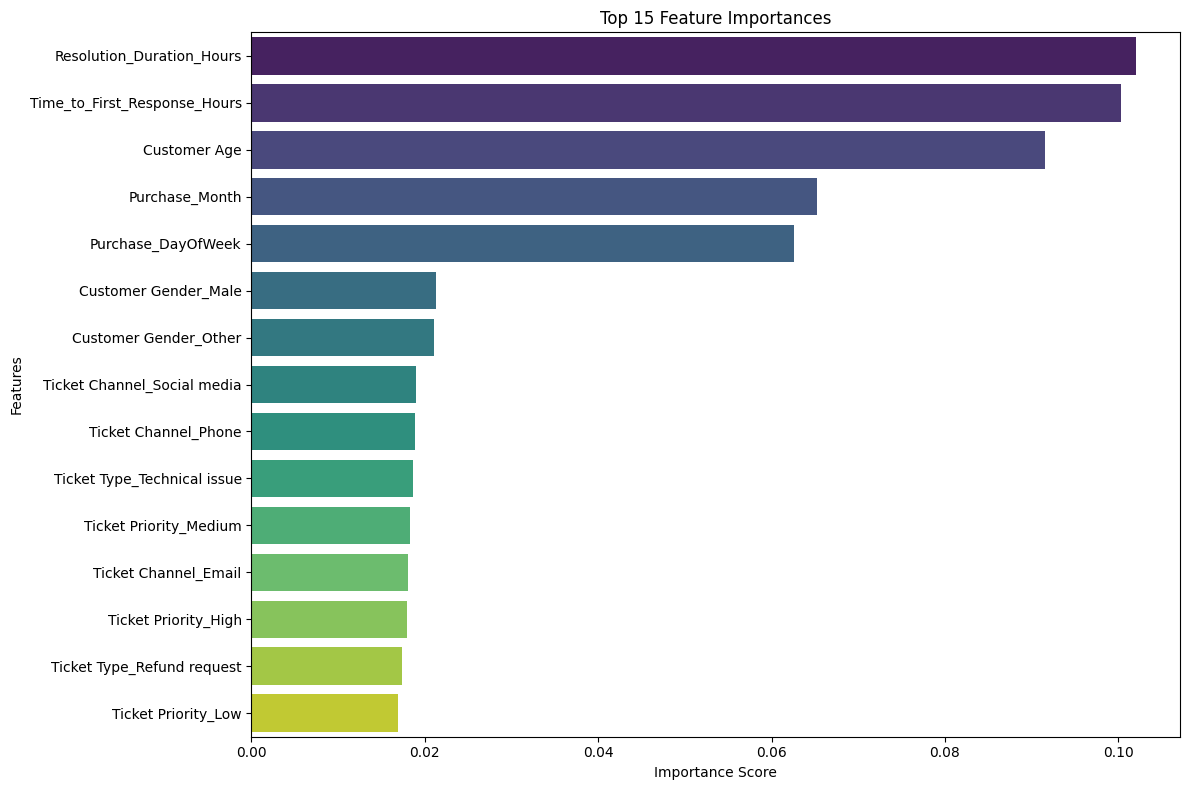

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the feature importances from the trained RandomForestClassifier model
feature_importances = model.feature_importances_

# 2. Create a pandas Series where the index is the feature names and the values are their corresponding importances
features_df = pd.Series(feature_importances, index=X.columns)

# 3. Sort this Series in descending order
top_features = features_df.sort_values(ascending=False).head(15)

# 4. Create a horizontal bar plot of the top 15 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


**Reasoning**:
The previous code generated a `FutureWarning` because the `palette` argument was used without `hue` in `sns.barplot`. I will modify the `sns.barplot` call to pass `y` to `hue` and set `legend=False` to resolve this warning. Additionally, I will implement the new instruction to visualize the distribution of the target variable `y` using a `countplot`.



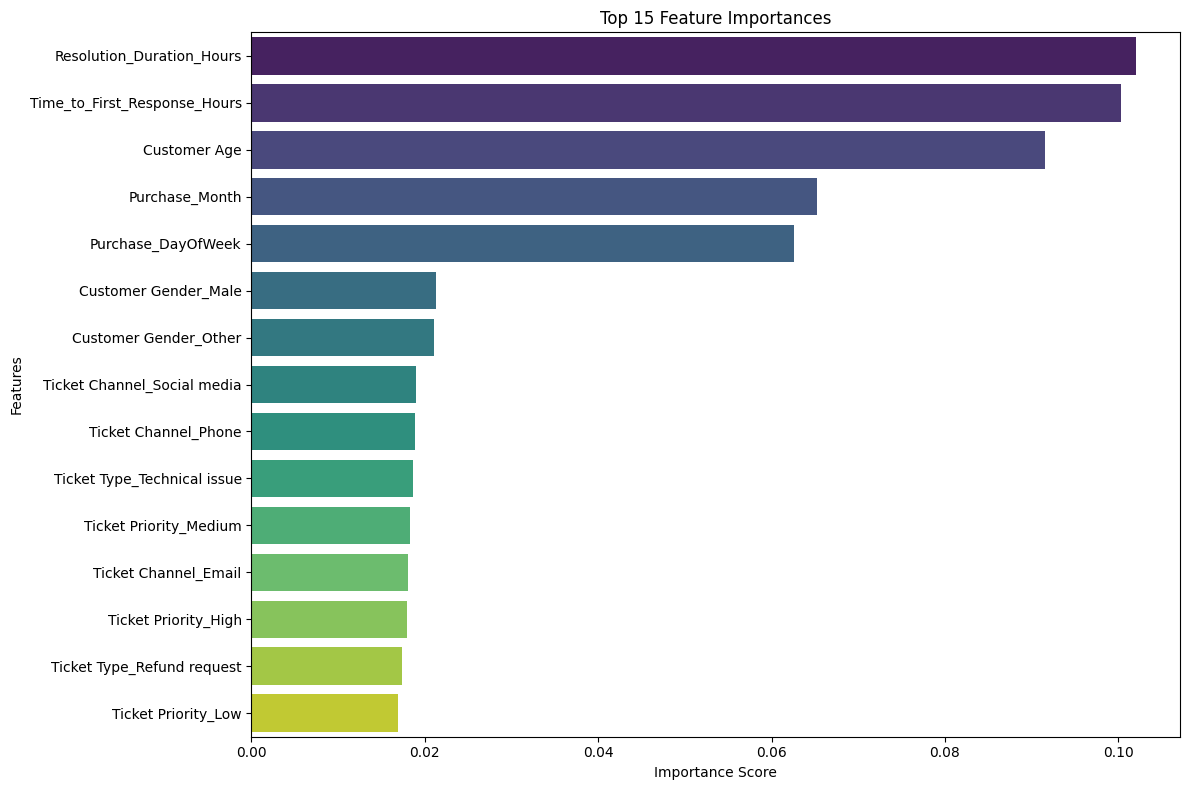

/tmp/ipykernel_271/1236919007.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


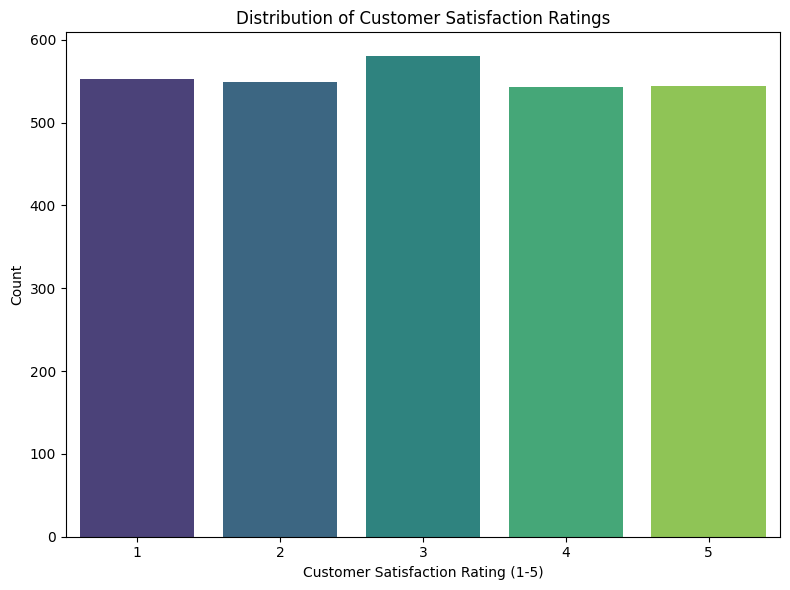

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the feature importances from the trained RandomForestClassifier model
feature_importances = model.feature_importances_

# 2. Create a pandas Series where the index is the feature names and the values are their corresponding importances
features_df = pd.Series(feature_importances, index=X.columns)

# 3. Sort this Series in descending order
top_features = features_df.sort_values(ascending=False).head(15)

# 4. Create a horizontal bar plot of the top 15 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', hue=top_features.index, legend=False)
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 5. Create a count plot to visualize the distribution of the Customer Satisfaction Rating (the y target variable)
plt.figure(figsize=(8, 6))
sns.countplot(x=y, palette='viridis')
plt.title('Distribution of Customer Satisfaction Ratings')
plt.xlabel('Customer Satisfaction Rating (1-5)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` for `sns.countplot` because `palette` was used without `hue`. I will modify the `sns.countplot` call to assign the `x` variable (`y` in this case) to `hue` and set `legend=False` to resolve this warning.



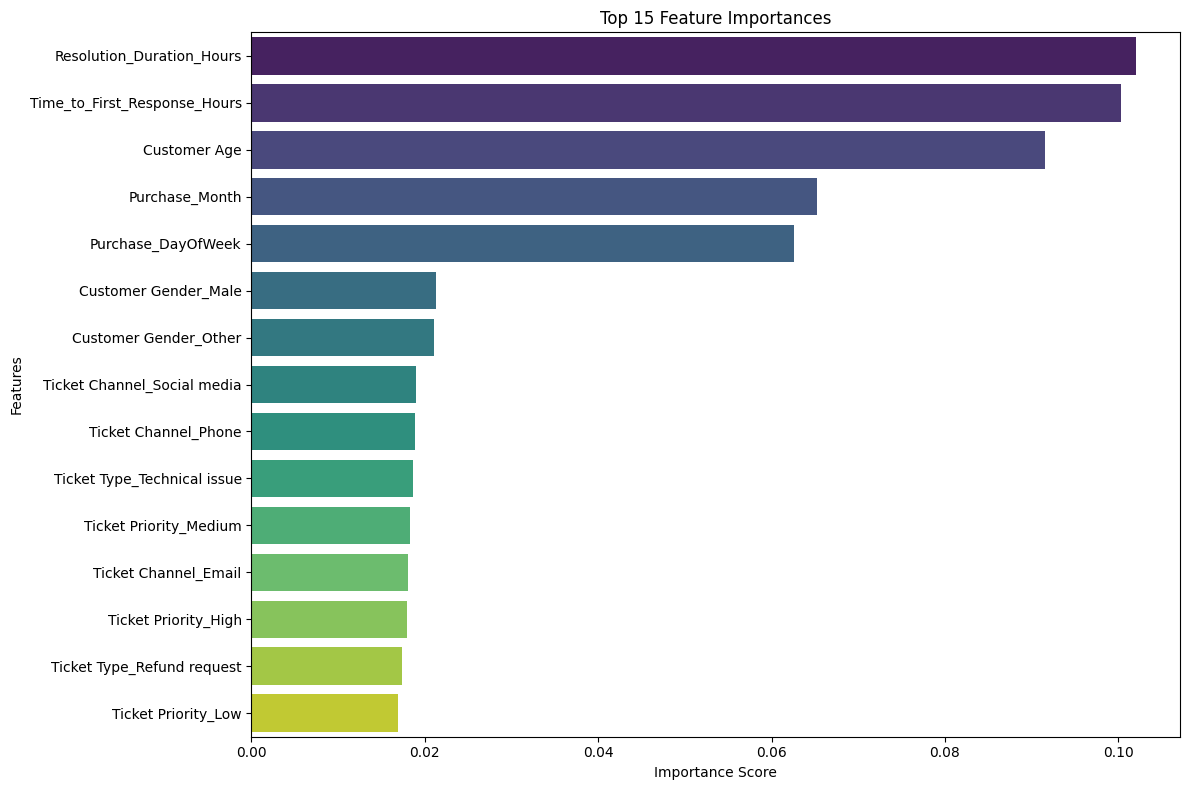

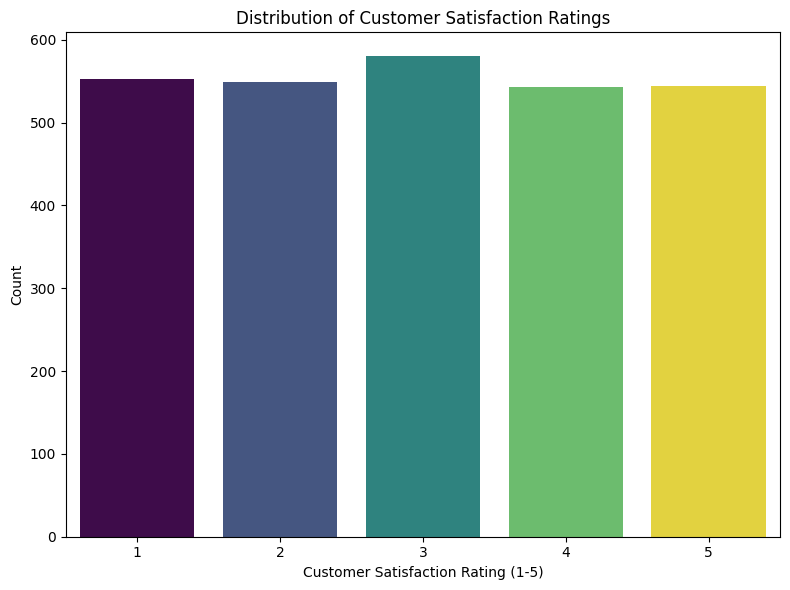

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the feature importances from the trained RandomForestClassifier model
feature_importances = model.feature_importances_

# 2. Create a pandas Series where the index is the feature names and the values are their corresponding importances
features_df = pd.Series(feature_importances, index=X.columns)

# 3. Sort this Series in descending order
top_features = features_df.sort_values(ascending=False).head(15)

# 4. Create a horizontal bar plot of the top 15 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', hue=top_features.index, legend=False)
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 5. Create a count plot to visualize the distribution of the Customer Satisfaction Rating (the y target variable)
plt.figure(figsize=(8, 6))
sns.countplot(x=y, palette='viridis', hue=y, legend=False)
plt.title('Distribution of Customer Satisfaction Ratings')
plt.xlabel('Customer Satisfaction Rating (1-5)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the developed model, its performance, and the key factors influencing customer satisfaction based on the analysis.


## Summary:

### Data Analysis Key Findings

*   **Initial Data State and Missing Values**: The original dataset contained 8469 entries. A substantial portion of the `Customer Satisfaction Rating` column (5700 out of 8469, approximately 67%) was missing. Similarly, `First Response Time`, `Time to Resolution`, and `Resolution` also had many missing values.
*   **Data Preparation for Modeling**: The dataset was filtered to include only entries with a non-null `Customer Satisfaction Rating`, reducing the effective dataset size from 8469 to 2769 entries.
*   **Feature Engineering**: New time-based features such as `Time_to_First_Response_Hours`, `Resolution_Duration_Hours`, `Purchase_DayOfWeek`, `Purchase_Month`, and `Purchase_Year` were created. Categorical features were one-hot encoded, and irrelevant columns (IDs, raw dates, text fields) were dropped, resulting in a final dataset with 2769 entries and 75 features.
*   **Target Variable Distribution**: The `Customer Satisfaction Rating` target variable, ranging from 1 to 5, showed a relatively balanced distribution across these categories for the available data.
*   **Model Performance**: A `RandomForestClassifier` model, trained on the processed data, achieved a very low accuracy of approximately 19.9% on the test set. The classification report indicated poor precision, recall, and F1-scores (between 0.17 and 0.27) across all customer satisfaction rating classes, suggesting the model performed little better than random guessing for five classes.
*   **Feature Importance**: Feature importance analysis was conducted and visualized, indicating the relative influence of various engineered and encoded features on customer satisfaction prediction.

### Insights or Next Steps

*   The current predictive model for customer satisfaction is not effective, achieving only ~20% accuracy. This performance is likely hindered by the significant reduction in data (over 67% of original entries) due to missing satisfaction ratings. Future efforts should explore strategies to handle these missing values more robustly or consider alternative modeling approaches.
*   Enhance feature engineering by incorporating Natural Language Processing (NLP) techniques on the `Ticket Description` and `Resolution` text columns, as these were dropped but could contain valuable sentiment or topic-related information crucial for predicting satisfaction.
